Tadas Riksas 2312087 ResNet, Ambulance, Banana, Parachute. With picture similarity comparison thing.

In [1]:
pip install torch torchvision scikit-image numpy matplotlib==3.10.8 pandas openimages seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
from torch import Generator
import torch
import pandas as pd
from skimage import io, transform
from skimage.color import gray2rgb
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from openimages.download import download_dataset
import torchvision.models as models
import glob
import torch.nn as nn   
from PIL import Image
from sklearn.metrics import classification_report
import seaborn as sns
import math
from os import error
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric

In [3]:
data_dir = "./data/"

if not os.path.exists(data_dir):
    error(f"Data directory {data_dir} does not exist. Please create it and add the dataset.")

In [4]:
IMAGE_SIZE = 256

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))
])

augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

In [5]:
class MyImages(Dataset):
    def __init__(self, path, augment=False):
        self.path = path
        self.images = os.listdir(path)
        self.augment = augment

        self.files  = glob.glob(os.path.join(path, "**", "*.JPEG"), recursive=True)
        self.files += glob.glob(os.path.join(path, "**", "*.jpg"),  recursive=True)
        self.files += glob.glob(os.path.join(path, "**", "*.png"),  recursive=True)
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        
        transform = augment_transform if self.augment else base_transform
        img = transform(img)
        
        img_np = np.array(img, dtype=np.float32) / 255.0   # [0, 1]
        lab    = rgb2lab(img_np).astype(np.float32)
        L  = lab[:, :, 0] / 50.0 - 1.0          # [0,100]    → [-1, 1]
        ab = lab[:, :, 1:] / 110.0               # [-128,127] → roughly [-1, 1]
        
        L  = torch.from_numpy(L).unsqueeze(0)        # (1, H, W)
        ab = torch.from_numpy(ab).permute(2, 0, 1)  # (2, H, W)
        
        return L, ab


In [6]:
# TRAIN_SPLIT = 0.2
# VAL_SPLIT = 0.01
# TEST_SPLIT = 0.01
TRAIN_SPLIT = 0.2
VAL_SPLIT = 0.001
TEST_SPLIT = 0.01
SEED = 1
BATCH_SIZE = 32

def get_dataloaders():
    full_dataset = MyImages(data_dir)
    
    train_size = math.floor(TRAIN_SPLIT * len(full_dataset))
    val_size = math.floor(VAL_SPLIT * len(full_dataset))
    test_size = math.floor(TEST_SPLIT * len(full_dataset))
    
    indices = torch.randperm(len(full_dataset), generator=Generator().manual_seed(SEED))

    train_idx = indices[:train_size]
    val_idx   = indices[train_size:train_size + val_size]
    test_idx  = indices[train_size + val_size:train_size + val_size + test_size]

    train_ds = torch.utils.data.Subset(MyImages(data_dir, augment=True), train_idx) # type: ignore
    val_ds   = torch.utils.data.Subset(MyImages(data_dir, augment=False), val_idx) # type: ignore
    test_ds  = torch.utils.data.Subset(MyImages(data_dir, augment=False), test_idx) # type: ignore
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, prefetch_factor=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=2)
    
    return train_loader, val_loader, test_loader

In [7]:
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False, activation="relu"):
        super().__init__()
        layers = []
        if down:
            layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else:
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        if dropout:
            layers.append(nn.Dropout(0.5))
        if activation == "relu":
            layers.append(nn.ReLU(inplace=True))
        elif activation == "leaky":
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.block(x)
    
    
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = UNetBlock(1,   64,  down=True, use_bn=False, activation="leaky")  # 128
        self.e2 = UNetBlock(64,  128, down=True, activation="leaky")                # 64
        self.e3 = UNetBlock(128, 256, down=True, activation="leaky")                # 32
        self.e4 = UNetBlock(256, 512, down=True, activation="leaky")                # 16
        self.e5 = UNetBlock(512, 512, down=True, activation="leaky")                # 8
        self.e6 = UNetBlock(512, 512, down=True, activation="leaky")                # 4
        self.e7 = UNetBlock(512, 512, down=True, activation="leaky")                # 2
        
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 4, 2, 1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder — in_ch doubles because of skip connections
        self.d1 = UNetBlock(512,  512, down=False, dropout=True)   # 2
        self.d2 = UNetBlock(1024, 512, down=False, dropout=True)   # 4
        self.d3 = UNetBlock(1024, 512, down=False, dropout=True)   # 8
        self.d4 = UNetBlock(1024, 512, down=False)                 # 16
        self.d5 = UNetBlock(1024, 256, down=False)                 # 32
        self.d6 = UNetBlock(512,  128, down=False)                 # 64
        self.d7 = UNetBlock(256,  64,  down=False)                 # 128
        
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 2, 4, 2, 1),
            nn.Tanh()
        )
        
    def forward(self, x):
        e1 = self.e1(x)  
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        bn = self.bottleneck(e7)
        d1 = self.d1(bn)
        d2 = self.d2(torch.cat([d1, e7], dim=1))
        d3 = self.d3(torch.cat([d2, e6], dim=1))
        d4 = self.d4(torch.cat([d3, e5], dim=1))
        d5 = self.d5(torch.cat([d4, e4], dim=1))
        d6 = self.d6(torch.cat([d5, e3], dim=1))
        d7 = self.d7(torch.cat([d6, e2], dim=1))
        final = self.final(torch.cat([d7, e1], dim=1))
        
        return final
    
    
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # input = L (1ch) + ab (2ch) = 3ch
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 1),
        )
        
    def forward(self, L, ab):
        return self.model(torch.cat([L, ab], dim=1))

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
def save_checkpoint(epoch, generator, discriminator, opt_g, opt_d, history, path):
    torch.save({
        "epoch":   epoch,
        "gen":     generator.state_dict(),
        "disc":    discriminator.state_dict(),
        "opt_g":   opt_g.state_dict(),
        "opt_d":   opt_d.state_dict(),
        "history": history,
    }, path)
    print(f"  [Checkpoint] Saved → {path}")
    
    
def load_checkpoint(path, generator, discriminator, opt_g, opt_d):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    generator.load_state_dict(ckpt["gen"])
    discriminator.load_state_dict(ckpt["disc"])
    opt_g.load_state_dict(ckpt["opt_g"])
    opt_d.load_state_dict(ckpt["opt_d"])
    print(f"  [Checkpoint] Resuming from epoch {ckpt['epoch']}")
    return ckpt["epoch"], ckpt["history"]

In [10]:
def lab_to_rgb_numpy(L, ab):
    L_np  = (L.squeeze().cpu().numpy() + 1.0) * 50.0
    ab_np = ab.permute(1, 2, 0).cpu().numpy() * 110.0
    lab   = np.concatenate([L_np[:, :, None], ab_np], axis=2)
    return np.clip(lab2rgb(lab.astype(np.float64)), 0, 1)
    
    
def compute_metrics(pred_ab, real_ab, L):
    psnr_vals, ssim_vals, mse_vals, mae_vals = [], [], [], []
    for i in range(pred_ab.size(0)):
        pred_rgb = lab_to_rgb_numpy(L[i], pred_ab[i])
        real_rgb = lab_to_rgb_numpy(L[i], real_ab[i])
        psnr_vals.append(psnr_metric(real_rgb, pred_rgb, data_range=1.0))
        ssim_vals.append(ssim_metric(real_rgb, pred_rgb, channel_axis=2, data_range=1.0))
        mse_vals.append(np.mean((real_rgb - pred_rgb) ** 2))
        mae_vals.append(np.mean(np.abs(real_rgb - pred_rgb)))
    return np.mean(psnr_vals), np.mean(ssim_vals), np.mean(mse_vals), np.mean(mae_vals)

In [ ]:
def prepare_L(image_path, base_transform, device):
    from skimage.color import rgb2lab
    from PIL import Image
    import numpy as np

    img = Image.open(image_path).convert("RGB")
    img = base_transform(img)

    img_np = np.array(img, dtype=np.float32) / 255.0
    lab = rgb2lab(img_np).astype(np.float32)

    L = torch.from_numpy(lab[:, :, 0] / 50.0 - 1.0)\
            .unsqueeze(0).unsqueeze(0).to(device)

    return (img, L)

def preview_from_L(generator, L_single):
    color_image = L_single[0]
    lab_image = L_single[1]
    
    generator.eval()
    with torch.no_grad():
        pred_ab = generator(lab_image)

    pred_rgb = lab_to_rgb_numpy(
        lab_image[0].cpu(),
        pred_ab[0].cpu()
    )

    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(
        (lab_image[0].squeeze().cpu().numpy() + 1.0) * 50.0,
        cmap="gray"
    )
    axes[0].set_title("Grayscale Input")
    axes[0].axis("off")

    axes[1].imshow(pred_rgb)
    axes[1].set_title("Colorized Output")
    axes[1].axis("off")
    
    axes[2].imshow(color_image)
    axes[2].set_title("Original Color Image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
import torch.nn.functional as F

NUM_EPOCHS    = 100
LEARNING_RATE_G = 2e-4
LEARNING_RATE_D = 1e-4
LAMBDA_L1 = 5

BEST_MODEL_PATH = "./best_model6.pth"
CHECKPOINT_EVERY = 5
CHECKPOINT_DIR = "./checkpoint6/"
SPEC_IMG = "./your_image.jpg"

L_single = prepare_L(SPEC_IMG, base_transform, DEVICE)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def train_model(generator, discriminator, train_loader, val_loader, resume_path=None):
    opt_g = torch.optim.Adam(generator.parameters(),     lr=LEARNING_RATE_G, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D, betas=(0.5, 0.999))

    criterion_L1  = nn.L1Loss()

    sched_g = torch.optim.lr_scheduler.StepLR(opt_g, step_size=100, gamma=0.5)
    sched_d = torch.optim.lr_scheduler.StepLR(opt_d, step_size=100, gamma=0.5)

    history = {"g_loss": [], "d_loss": [], "psnr": [], "ssim": [], "mse": [], "mae": []}
    start_epoch = 0
    best_psnr = 0.0

    if resume_path:
        if os.path.exists(resume_path):
            start_epoch, history = load_checkpoint(resume_path, generator, discriminator, opt_g, opt_d)
        else:
            raise FileNotFoundError(f"Checkpoint {resume_path} not found. Cannot resume training.")

    for epoch in range(start_epoch, NUM_EPOCHS):
        generator.train()
        discriminator.train()
        epoch_g_loss, epoch_d_loss, n_batches = 0.0, 0.0, 0

        for L, real_ab in train_loader:
            L = L.to(DEVICE)
            real_ab = real_ab.to(DEVICE)
            B = L.size(0)

            # Train Discriminator
            if n_batches % 2 == 0:
                opt_d.zero_grad()
                with torch.no_grad():
                    pred_ab = generator(L)

                real_out = discriminator(L, real_ab)
                fake_out = discriminator(L, pred_ab)

                loss_d = torch.mean(F.relu(1.0 - real_out)) + \
                        torch.mean(F.relu(1.0 + fake_out))

                loss_d.backward()
                opt_d.step()
                
                epoch_d_loss += loss_d.item()

            # Train Generator
            opt_g.zero_grad()

            pred_ab = generator(L)
            fake_out = discriminator(L, pred_ab)

            loss_g = -torch.mean(fake_out) + \
                    LAMBDA_L1 * criterion_L1(pred_ab, real_ab)

            loss_g.backward()
            opt_g.step()

            epoch_g_loss += loss_g.item()
            
            
            n_batches    += 1

        sched_g.step()
        sched_d.step()

        # Validation
        generator.eval()
        psnr_list, ssim_list, mse_list, mae_list = [], [], [], []
        with torch.no_grad():
            for L, real_ab in val_loader:
                L, real_ab = L.to(DEVICE), real_ab.to(DEVICE)
                pred_ab    = generator(L)
                p, s, m, a = compute_metrics(pred_ab, real_ab, L)
                psnr_list.append(p); ssim_list.append(s)
                mse_list.append(m);  mae_list.append(a)

        avg_g = epoch_g_loss / n_batches
        avg_d = epoch_d_loss / n_batches * 2
        mean_psnr = np.mean(psnr_list) 
        mean_ssim = np.mean(ssim_list)
        mean_mse  = np.mean(mse_list) 
        mean_mae  = np.mean(mae_list)

        history["g_loss"].append(avg_g) 
        history["d_loss"].append(avg_d)
        history["psnr"].append(mean_psnr)
        history["ssim"].append(mean_ssim)
        history["mse"].append(mean_mse)
        history["mae"].append(mean_mae)
            
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  G: {avg_g:.4f}  D: {avg_d:.4f} | "
              f"PSNR: {mean_psnr:.2f}  SSIM: {mean_ssim:.4f}  MSE: {mean_mse:.5f}  MAE: {mean_mae:.5f}")

        if mean_psnr > best_psnr:
            best_psnr = mean_psnr
            torch.save(generator.state_dict(), BEST_MODEL_PATH)
            print(f"  [Best] PSNR {best_psnr:.2f} → {BEST_MODEL_PATH}")

        if (epoch + 1) % CHECKPOINT_EVERY == 0:
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pth")
            save_checkpoint(epoch + 1, generator, discriminator, opt_g, opt_d, history, ckpt_path)
            
        if (epoch + 1) % 1 == 0:
            print("  [Preview]")
            preview_from_L(generator, L_single)
            
    return history

In [12]:
train_loader, val_loader, test_loader = get_dataloaders()

In [ ]:
generator     = UNetGenerator().to(DEVICE)
discriminator = PatchGANDiscriminator().to(DEVICE)
 
history = train_model(generator, discriminator, train_loader, val_loader)

Epoch [  1/10]  G: 1.5994  D: 2.0625 | PSNR: 17.17  SSIM: 0.5476  MSE: 0.02428  MAE: 0.09782
  [Best] PSNR 17.17 → ./best_model6.pth
Epoch [  2/10]  G: 1.0104  D: 1.9506 | PSNR: 17.89  SSIM: 0.5585  MSE: 0.02071  MAE: 0.09102
  [Best] PSNR 17.89 → ./best_model6.pth
Epoch [  3/10]  G: 1.0034  D: 1.8063 | PSNR: 18.31  SSIM: 0.5845  MSE: 0.01822  MAE: 0.08727
  [Best] PSNR 18.31 → ./best_model6.pth
Epoch [  4/10]  G: 1.1135  D: 1.7422 | PSNR: 15.98  SSIM: 0.5221  MSE: 0.03259  MAE: 0.10994
Epoch [  5/10]  G: 1.1781  D: 1.8238 | PSNR: 17.75  SSIM: 0.5620  MSE: 0.01984  MAE: 0.09124
  [Checkpoint] Saved → ./checkpoint6/checkpoint_epoch_5.pth
Epoch [  6/10]  G: 1.1425  D: 1.6922 | PSNR: 18.24  SSIM: 0.6174  MSE: 0.01842  MAE: 0.08420
Epoch [  7/10]  G: 1.2700  D: 1.3522 | PSNR: 17.83  SSIM: 0.6018  MSE: 0.02100  MAE: 0.08966
Epoch [  8/10]  G: 1.2425  D: 1.4531 | PSNR: 18.70  SSIM: 0.6401  MSE: 0.01968  MAE: 0.08612
  [Best] PSNR 18.70 → ./best_model6.pth
Epoch [  9/10]  G: 1.3412  D: 1.4765

In [ ]:
def plot_training_history(history):
    epochs = range(1, len(history["g_loss"]) + 1)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("pix2pix Training History", fontsize=16)
    
    axes[0, 0].plot(epochs, history["g_loss"], label="Generator Loss")
    axes[0, 0].plot(epochs, history["d_loss"], label="Discriminator Loss")
    axes[0, 0].set(title="GAN Losses", xlabel="Epoch", ylabel="Loss")
    axes[0, 0].legend()
    
    axes[0, 1].plot(epochs, history["psnr"], color="green")
    axes[0, 1].set(title="PSNR (Higher is Better)", xlabel="Epoch", ylabel="dB")
    
    axes[0, 2].plot(epochs, history["ssim"], color="purple")
    axes[0, 2].set(title="SSIM (Higher is Better)", xlabel="Epoch", ylabel="SSIM")
    
    axes[1, 0].plot(epochs, history["mse"], color="red")
    axes[1, 0].set(title="MSE (Lower is Better)", xlabel="Epoch", ylabel="MSE")
    
    axes[1, 1].plot(epochs, history["mae"], color="orange")
    axes[1, 1].set(title="MAE (Lower is Better)", xlabel="Epoch", ylabel="MAE")
    
    axes[1, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

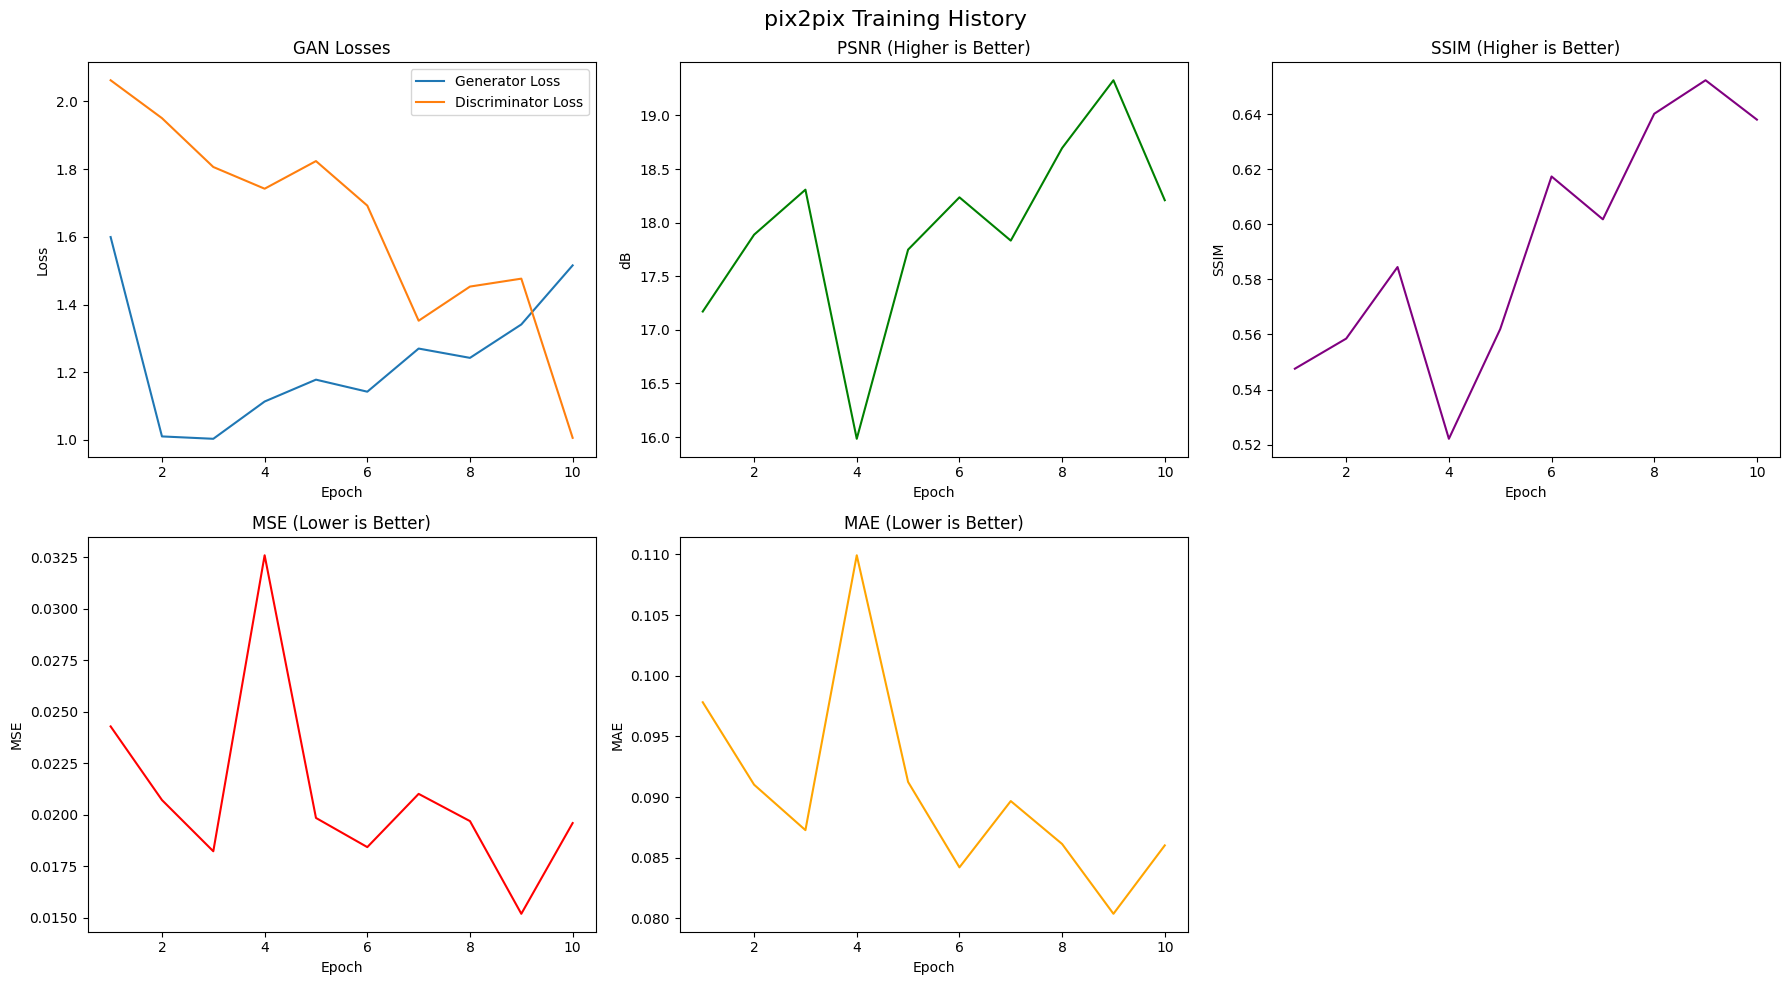

In [ ]:
plot_training_history(history)

In [ ]:
generator.load_state_dict(torch.load("./checkpoint5/checkpoint_epoch_5.pth", map_location=DEVICE, weights_only=False)["gen"])
generator.eval()
    
all_psnr, all_ssim, all_mse, all_mae = [], [], [], []
with torch.no_grad():
    for L, real_ab in test_loader:
        L, real_ab = L.to(DEVICE), real_ab.to(DEVICE)
        pred_ab    = generator(L)
        p, s, m, a = compute_metrics(pred_ab, real_ab, L)
        all_psnr.append(p); all_ssim.append(s)
        all_mse.append(m);  all_mae.append(a)
    
print(f"Test Set Results:")
print(f"  PSNR : {np.mean(all_psnr):.4f} dB")
print(f"  SSIM : {np.mean(all_ssim):.4f}")
print(f"  MSE  : {np.mean(all_mse):.6f}")
print(f"  MAE  : {np.mean(all_mae):.6f}")

Test Set Results:
  PSNR : 16.6629 dB
  SSIM : 0.5291
  MSE  : 0.027010
  MAE  : 0.107541


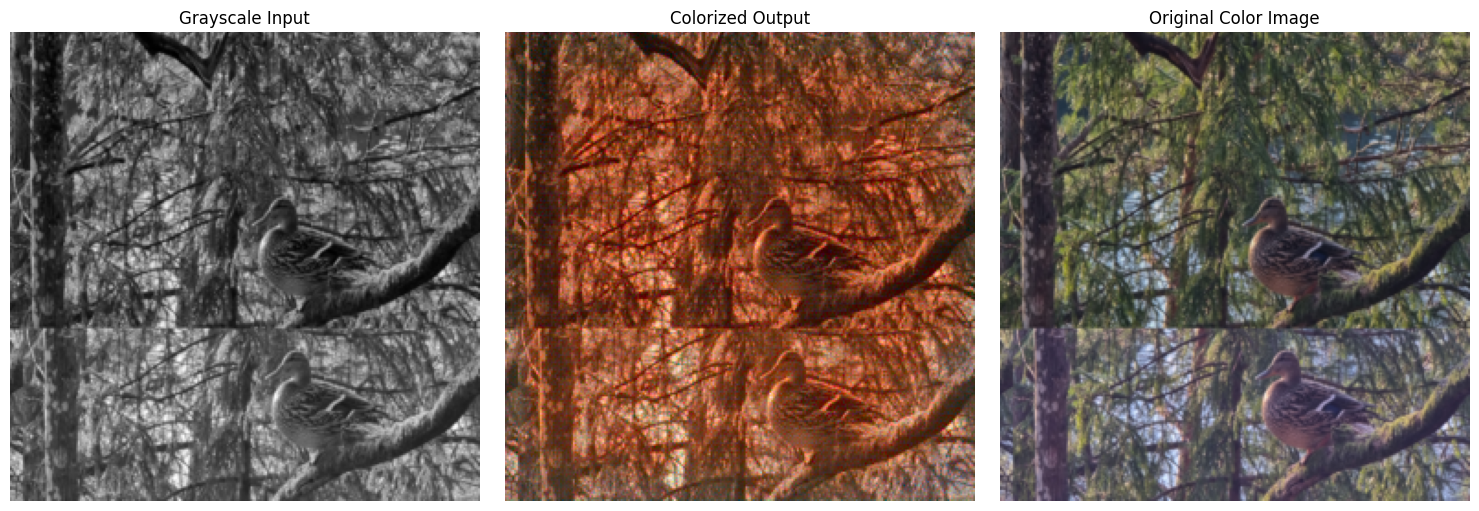

In [ ]:
my_image = "./your_image.jpg"
load_image = prepare_L(my_image, base_transform, DEVICE)
preview_from_L(generator, load_image)